# **Business Problem**

### Many businesses receive thousands of customer reviews every day. Manually analyzing these reviews is time-consuming and inefficient. The challenge is to automatically determine customer sentiment (Positive, Neutral, or Negative) and extract meaningful insights that help improve products and customer satisfaction

# **Project Goal**

### Develop a sentiment analysis model using Natural Language Processing (NLP) techniques to classify Amazon customer reviews into Positive, Neutral, and Negative sentiments and generate business insights from customer feedback.

# **Objectives**


### Analyze Amazon customer reviews.

### Clean and preprocess text data.

### Perform Exploratory Data Analysis (EDA).

### Apply NLP techniques.

### Classify customer sentiment.

### Visualize sentiment distribution.

### Provide actionable business recommendations.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Reviews.csv')

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.tail()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...
568453,568454,B001LR2CU2,A3LGQPJCZVL9UC,srfell17,0,0,5,1338422400,Great Honey,"I am very satisfied ,product is as advertised,..."


In [ ]:
df.shape

(568454, 10)

In [ ]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [ ]:
df['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


In [ ]:
def sentiment(score):

    if score <=2:
        return "Negative"

    elif score==3:
        return "Neutral"

    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment)

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive


In [ ]:
df.to_csv("Cleaned_Amazon_Reviews.csv",index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Set figure size
plt.rcParams['figure.figsize'] = (10,6)

/tmp/ipykernel_2797/1255228158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


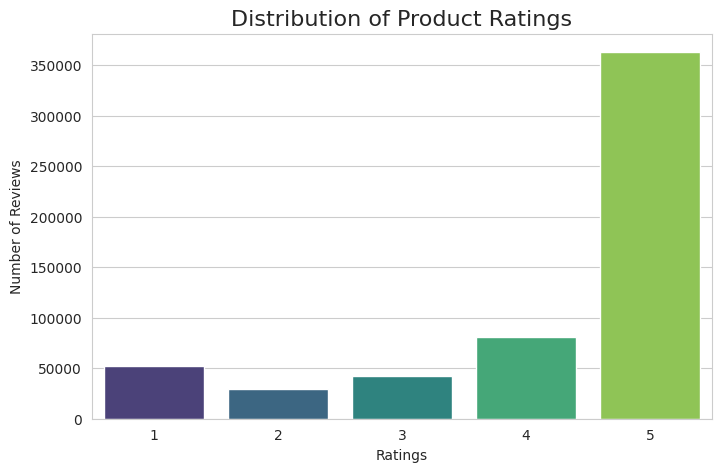

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Score',
    data=df,
    palette='viridis'
)

plt.title('Distribution of Product Ratings', fontsize=16)
plt.xlabel('Ratings')
plt.ylabel('Number of Reviews')

plt.show()

###

/tmp/ipykernel_2797/3657199462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


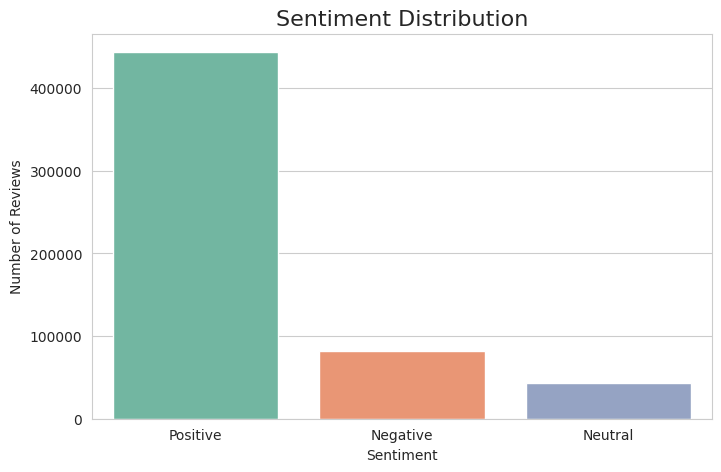

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    palette='Set2'
)

plt.title('Sentiment Distribution', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

###

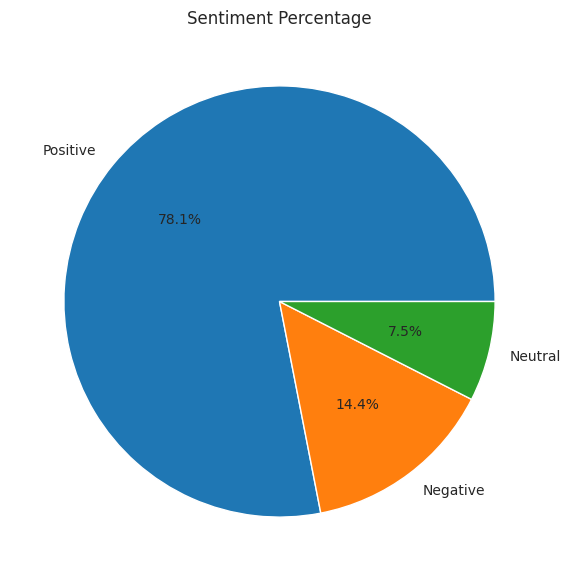

In [ ]:
plt.figure(figsize=(7,7))

df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Sentiment Percentage')

plt.ylabel('')

plt.show()

###

In [ ]:
df['Review_Length'] = df['Text'].apply(len)

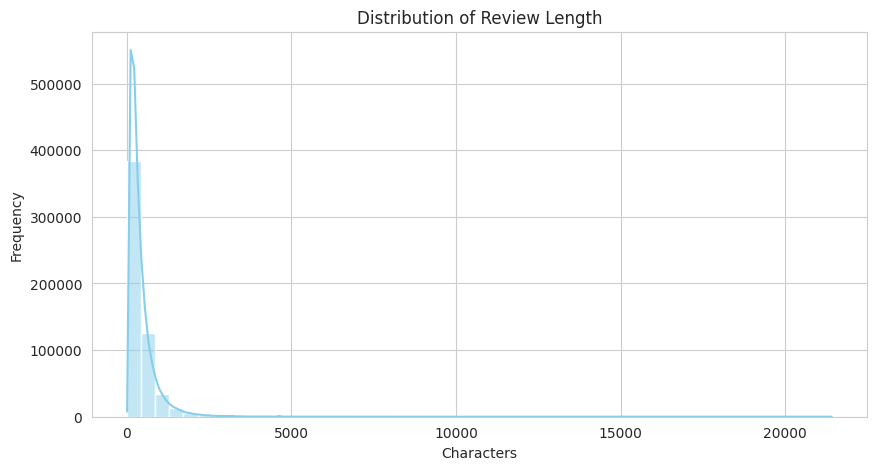

In [ ]:

plt.figure(figsize=(10,5))

sns.histplot(
    df['Review_Length'],
    bins=50,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of Review Length')

plt.xlabel('Characters')

plt.ylabel('Frequency')

plt.show()

###

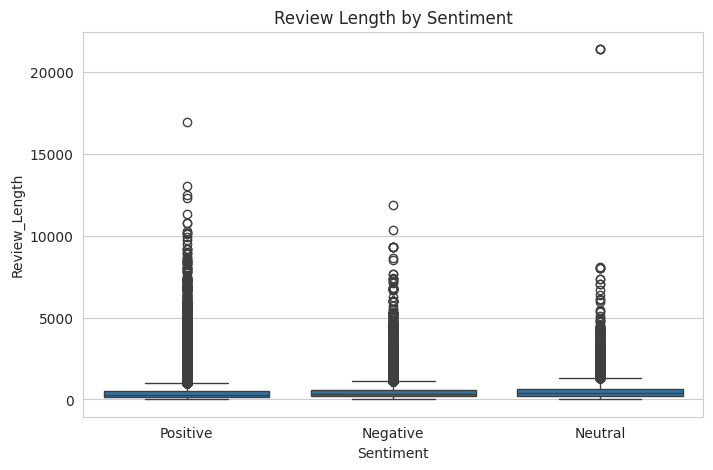

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Sentiment',
    y='Review_Length',
    data=df
)

plt.title('Review Length by Sentiment')

plt.show()

###

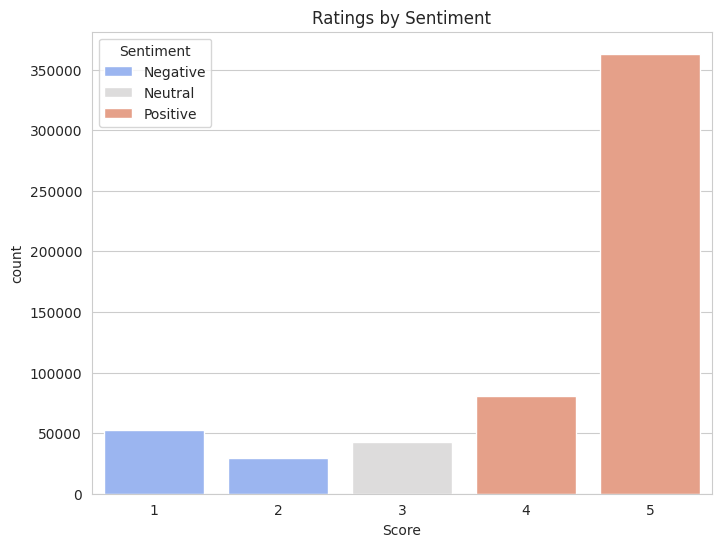

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='Score',
    hue='Sentiment',
    data=df,
    palette='coolwarm'
)

plt.title('Ratings by Sentiment')

plt.show()

###

In [ ]:
numeric_df = df[['Score',
                 'HelpfulnessNumerator',
                 'HelpfulnessDenominator',
                 'Review_Length']]

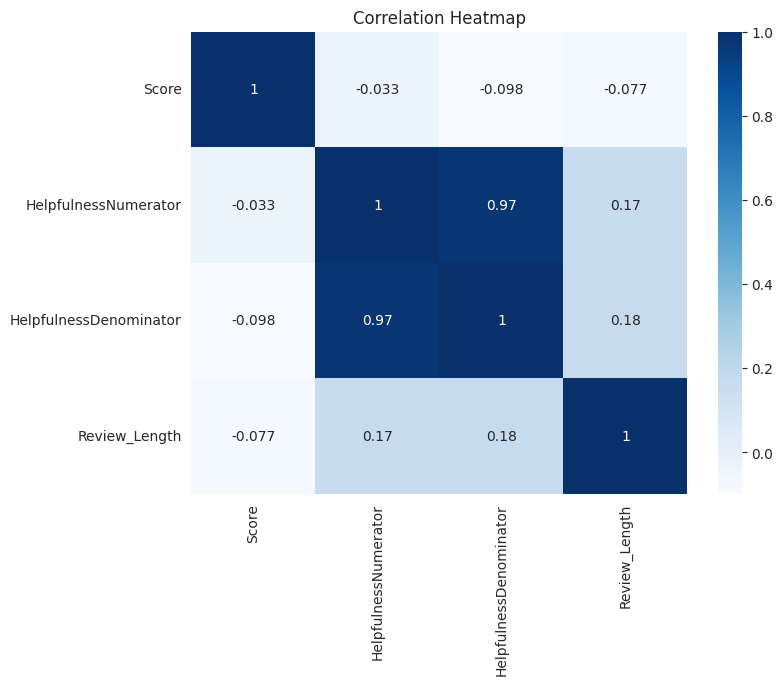

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')

plt.show()

### Review length shows a moderate relationship with helpfulness,while ratings has relatively very weak coorelations with the other numerical variables

# **1. Analyze text data to classify it as Positive, Negative, or Neutral**

In [58]:
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Score'].apply(sentiment)

df[['Score','Sentiment']].head()

,Score,Sentiment
0,5,Positive
1,1,Negative
2,4,Positive
3,2,Negative
4,5,Positive


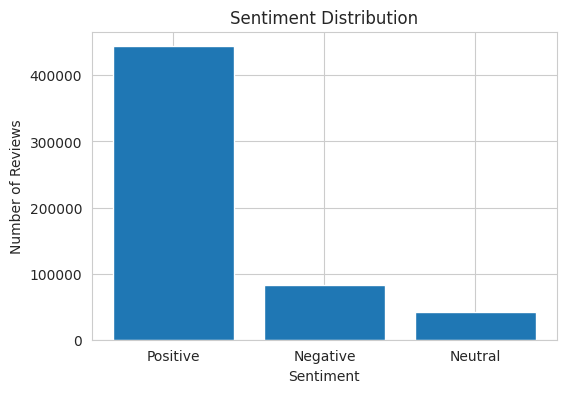

In [59]:
import matplotlib.pyplot as plt

sentiment_count = df['Sentiment'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    # Join words
    return " ".join(words)

In [ ]:
df['Cleaned_Text'] = df['Text'].astype(str).apply(preprocess_text)

In [ ]:
print("Original Review:\n")
print(df['Text'][0])

print("\nCleaned Review:\n")
print(df['Cleaned_Text'][0])

Original Review:

I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned Review:

bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


In [ ]:
df['Cleaned_Text'].isnull().sum()

np.int64(0)

 ## **2. Use NLP techniques and lexicons to detect specific emotions**

### Besides Positive/Negative/Neutral, your task specifically asks for emotion detection.

In [ ]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [ ]:
review = df['Text'][0]

scores = sia.polarity_scores(review)

print(scores)

{'neg': 0.0, 'neu': 0.695, 'pos': 0.305, 'compound': 0.9441}


In [ ]:
def vader_sentiment(text):
    score = sia.polarity_scores(str(text))

    if score['compound'] >= 0.05:
        return "Positive"
    elif score['compound'] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['VADER_Sentiment'] = df['Text'].apply(vader_sentiment)

df[['Text','VADER_Sentiment']].head()

,Text,VADER_Sentiment
0,I have bought several of the Vitality canned d...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,This is a confection that has been around a fe...,Positive
3,If you are looking for the secret ingredient i...,Neutral
4,Great taffy at a great price. There was a wid...,Positive


## **3. Apply analysis on Amazon Reviews**

In [ ]:
sentiment_percent = (
    df['VADER_Sentiment']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(sentiment_percent)

VADER_Sentiment
Positive    87.43
Negative    10.44
Neutral      2.14
Name: proportion, dtype: float64


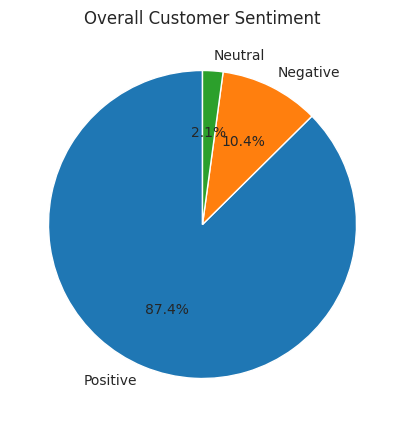

In [ ]:
plt.figure(figsize=(7,5))

plt.pie(
    sentiment_percent.values,
    labels=sentiment_percent.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Overall Customer Sentiment")

plt.show()

# **4. Understand public opinion and trends**

In [ ]:
df.groupby('VADER_Sentiment')['Score'].mean()

,Score
VADER_Sentiment,
Negative,2.588085
Neutral,3.389081
Positive,4.393048


In [ ]:
df['VADER_Sentiment'].value_counts()

,count
VADER_Sentiment,
Positive,496975
Negative,59335
Neutral,12144


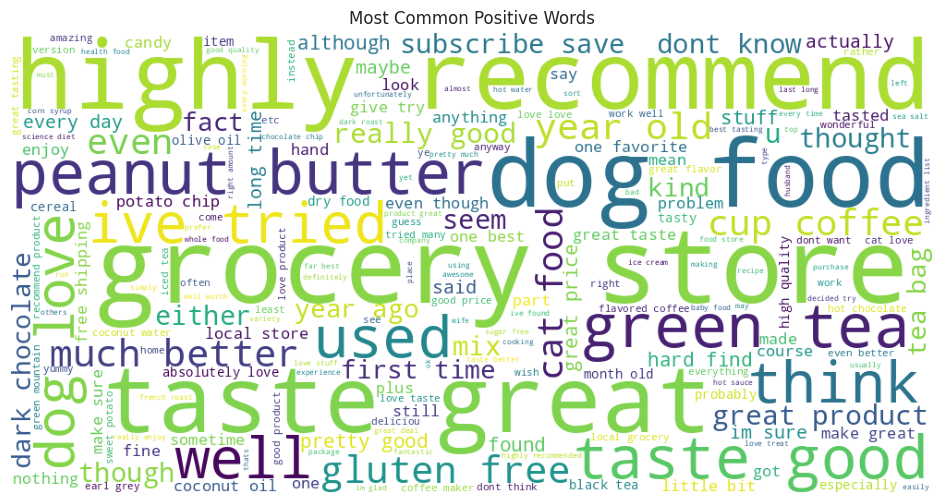

In [ ]:
from wordcloud import WordCloud

positive_reviews = " ".join(
    df[df['VADER_Sentiment']=="Positive"]['Cleaned_Text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Positive Words")
plt.show()

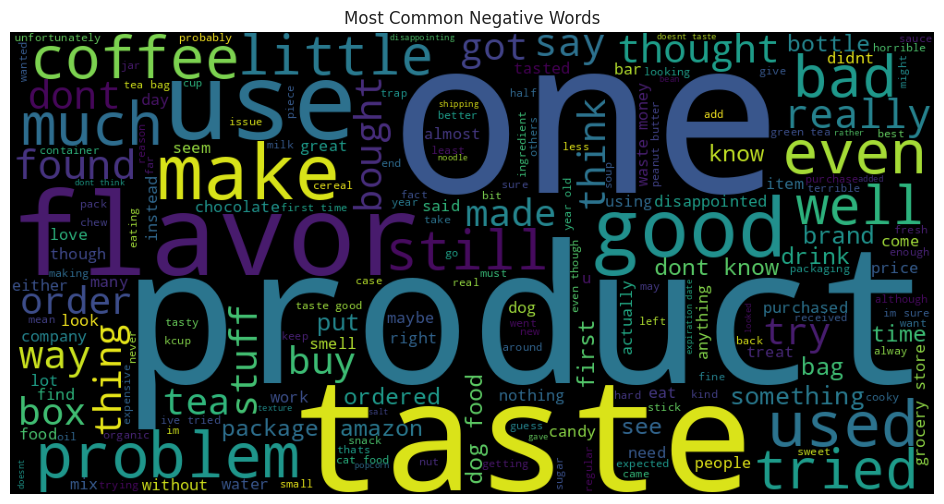

In [ ]:
negative_reviews = " ".join(
    df[df['VADER_Sentiment']=="Negative"]['Cleaned_Text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Negative Words")
plt.show()

# **5. Inform marketing, product development, or social insights**



# **Marketing Insights**

*    ### Most reviews are positive, indicating strong customer satisfaction.

*    ### Positive keywords (e.g., "delicious", "fresh", "quality") can be highlighted in advertising campaigns.

# **Product Development**

*    ### Negative reviews often mention issues like "stale", "broken", "late", or "expired".

*    ### These recurring complaints can guide improvements in packaging, shipping, and quality control.

# **Customer Experience**

*    ### Neutral reviews represent opportunities to improve products or service quality and convert these customers into promoters.



# **Business Recommendations**



## Based on the sentiment analysis of Amazon Food Reviews, the following recommendations can help improve business performance and customer satisfaction:

# **1** )**Enhance Product Quality**

*    ### Identify products receiving frequent negative feedback and investigate issues related to taste, freshness, packaging, or quality.

*   ### Implement stricter quality control measures to reduce customer complaints.

# **2** )**Improve Customer Experience**

*   ### Respond promptly to negative reviews and address customer concerns.
*   ### Encourage satisfied customers to leave detailed reviews, helping build trust among potential buyers.


# **3** )**Optimize Marketing Strategies**

*    ### Use positive customer feedback and commonly praised features in advertising campaigns.

*    ### ighlight strengths such as product quality, flavor, freshness, and value for money in promotional content.

# **4** )**Product Development**

*    ### Analyze recurring negative keywords to identify opportunities for product improvement.

*    ### Use customer suggestions to develop new products or enhance existing ones based on consumer preferences.

# **5** )**Monitor Customer Sentiment Regularly**

*   ### Perform periodic sentiment analysis to track changes in customer opinions.

*   ### Use sentiment trends as an early warning system for potential product or service issues.

# **5. Feature Extraction using TF-IDF**

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(df['Cleaned_Text'])

print(X.shape)

(568454, 5000)


## Prepare Target Variable

In [ ]:
y = df['Score']

In [60]:
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Score'].apply(sentiment)

In [61]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['Sentiment'])

print(encoder.classes_)

['Negative' 'Neutral' 'Positive']


## Train-Test Split

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Train the Model

In [65]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

## Make Predictions

In [66]:
y_pred = model.predict(X_test)

## Evaluate the Model

In [67]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8178307869576308


In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.27      0.41     16181
           1       0.44      0.00      0.00      8485
           2       0.82      1.00      0.90     89025

    accuracy                           0.82    113691
   macro avg       0.70      0.42      0.44    113691
weighted avg       0.79      0.82      0.76    113691



In [69]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 4377    14 11790]
 [  458    16  8011]
 [  432     6 88587]]


## Predict Sentiment for New Reviews

In [70]:
review = ["This product tastes amazing and I will definitely buy it again."]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

print(encoder.inverse_transform(prediction))

['Positive']


In [71]:
review = ["Worst product ever. Completely disappointed."]

# **Conclusion**



*    ### This project successfully analyzed customer reviews from the Amazon Fine Food Reviews dataset using Natural Language Processing (NLP) techniques. The text data was preprocessed by removing noise, stop words, punctuation, and applying lemmatization. Customer sentiments were then classified into Positive, Negative, and Neutral categories using both machine learning and lexicon-based approaches.

*   ### The analysis provided valuable insights into customer opinions, identified common themes in positive and negative reviews, and highlighted opportunities for business improvement. The findings demonstrate how sentiment analysis can support data-driven decision-making in areas such as product quality, marketing strategy, customer experience, and product development.

*   ### Overall, this project showcases the practical application of NLP and sentiment analysis in transforming unstructured customer feedback into meaningful business insights.


# Thank You!

## Thank you for reviewing this project.

### This project demonstrates the practical application of Natural Language Processing (NLP) and Sentiment Analysis to extract meaningful insights from customer reviews. It reflects my skills in Python, Data Preprocessing, NLP, Machine Learning, Data Visualization, and Business Analytics.

## I appreciate your time and feedback.

